<sub>Developed by SeongKu Kang, August 2025 — Do not distribute</sub>

# 📘 Task 1: Product category classification with limited labels (Fixed BERT embeddings)

In this notebook, we explore methods to improve classification performance in **limited label scenarios**.  
Unlike the full-label setting, where all training products have annotated category labels, here only a small subset is labeled.  
This mimics realistic situations in industry where annotations are expensive and only partially available.

We will attempt two approaches to handle this challenge:

1. **Label Embeddings**  
   - Instead of treating category labels as discrete IDs, we represent each label with its **semantic embedding** (i.e., using BERT embeddings of category names).  
   - This allows the model to leverage semantic similarity between categories (e.g., *"knitting hooks"* and *"crochet hooks"* are closer than *"knitting hooks"* and *"laptops"*).  
   - Goal: improve generalization, especially when labeled data is sparse.  

2. **Self-Training (Pseudo-Labeling)**  
   - We first train a model on the limited labeled dataset.  
   - Then, we use this model to generate **pseudo-labels** for the unlabeled products.  
   - These pseudo-labeled products are added back into the training set, and the model is retrained.  
   - Goal: effectively utilize the large pool of unlabeled data to boost classification accuracy.

We aim to understand how semantic knowledge and unlabeled data can help in **limited supervision environments**.

In [36]:
import json
from tqdm import tqdm
from pathlib import Path
from utils import * 
import copy

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

In [37]:
# Default paths
ROOT = Path("../assignment_release/dataset") # Root dataset directory
CORPUS_PATH = ROOT / "corpus.jsonl" # Product corpus file (JSON Lines): Each line contains a product ID and its associated text description.
EMB_PATH = ROOT / "corpus_bert_mean.pt"

# Task 1: Product category classification
LABEL_MAP_PATH = ROOT / "category_classification" 
LABEL2ID_PATH = LABEL_MAP_PATH / "label2labelid.json" 
ID2LABEL_PATH = LABEL_MAP_PATH / "labelid2label.json" 
PID2LABEL_TRAIN_PATH = LABEL_MAP_PATH / "pid2labelids_train.json"
PID2LABEL_TEST_PATH = LABEL_MAP_PATH / "pid2labelids_test.json" 
LABEL_EMB_PATH = LABEL_MAP_PATH / "category_labels_bert_mean.pt"

# === Load limited label training set (subset of pid2labelids_train) ===
PID2LABEL_TRAIN_LIMITED_PATH = LABEL_MAP_PATH / "pid2labelids_train_limited.json" 

In [38]:
pid2text = load_corpus(CORPUS_PATH) # load corpus

label2id = load_json(LABEL2ID_PATH)
id2label = load_json(ID2LABEL_PATH)
pid2label_train_limited = load_json(PID2LABEL_TRAIN_LIMITED_PATH)
pid2label_test = load_json(PID2LABEL_TEST_PATH)

# loading pre-trained embeddings
corpus_data = torch.load(EMB_PATH)  # {"ids": [...], "embeddings": Tensor}
pid_list = corpus_data["ids"]
pid2idx = {pid: i for i, pid in enumerate(pid_list)}
embeddings = corpus_data["embeddings"]

label_data = torch.load(LABEL_EMB_PATH)
label_emb = label_data["embeddings"].to(device)

In [39]:
class ProductCategoryEmbeddingDataset(Dataset):
    def __init__(self, pid2label, pid2idx, embeddings):
        self.pids = list(pid2label.keys())
        self.labels = [pid2label[pid] for pid in self.pids]
        self.indices = [pid2idx[pid] for pid in self.pids]
        self.embeddings = embeddings

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        emb = self.embeddings[self.indices[idx]]
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return {"X": emb, "y": label}

In [40]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, dataloader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            X = batch["X"].to(device)
            y = batch["y"].to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return {"accuracy": acc, "f1_macro": f1_macro}

In [41]:
# Build test dataset and dataloader from precomputed embeddings
test_dataset = ProductCategoryEmbeddingDataset(pid2label_test, pid2idx, embeddings)
test_loader = DataLoader(test_dataset, batch_size=64)

# Model dimensions
input_dim = embeddings.shape[1]   # Size of embedding vector (feature dimension)
num_classes = len(label2id)       # Number of category classes

# Keep track of product IDs
all_pids = set(pid_list)
test_pids = set(pid2label_test.keys())

In [42]:
# Build dataset with limited labeled products
train_dataset = ProductCategoryEmbeddingDataset(pid2label_train_limited, pid2idx, embeddings)

# Split into train/validation sets (80% / 20%)
val_ratio = 0.2
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size

train_split, val_split = random_split(train_dataset, [train_size, val_size])

# DataLoaders for training and validation
train_loader = DataLoader(train_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_split, batch_size=64)

In [43]:
# Find products without labels
used_pids = set(pid2label_train_limited.keys())
unlabeled_pids = all_pids - used_pids

# Ratio of unlabeled products in the whole corpus
unlabeled_ratio = len(unlabeled_pids) / len(all_pids)

print(f"[Unlabeled] {len(unlabeled_pids)} / {len(all_pids)} = {unlabeled_ratio:.2%}")

[Unlabeled] 32810 / 39452 = 83.16%


In [44]:
results_dict = {'valid':{}, 'test': {}}

## [Part A] Approach 1: Label Embedding Classifier

In the standard classification setup, each label is represented as a one-hot ID, and the model learns a linear classifier over these IDs.  
This ignores the fact that **labels themselves carry semantic meaning** (e.g., *"Knitting & Crochet"* is semantically closer to *"Sewing"* than to *"Laptops"*).  

To exploit this, we use **label embeddings**:  
- Each category is represented by a dense embedding vector (e.g., obtained by encoding the label text with BERT).  
- Instead of learning a weight vector for each class independently, the model projects the input product embedding into the same space as the label embeddings.  
- Prediction is made by computing the **inner product (similarity)** between the projected input and all label embeddings.  

Formally:  

$$
\text{logits}(x) = \text{Proj}(x) \cdot E^T
$$

where  
- $\text{Proj}(x)$ is the projected input representation,  
- $E$ is the matrix of label embeddings.  

**Benefits in limited supervision:**  
1. **Semantic transfer** – labels that are semantically related share embedding space, so the model can generalize better to underrepresented classes.  
2. **Compactness** – the model only needs to learn a projection into the label embedding space, rather than learning an independent classifier for each label.  

We can also choose to keep the label embeddings **fixed** (frozen, relying purely on semantic prior) or **trainable** (allowing fine-tuning for the specific dataset).


In [45]:
import torch.nn as nn
import torch.nn.functional as F

# Classifier that uses label embeddings to make predictions
class InnerProductClassifier(nn.Module):
    def __init__(self, input_dim, label_embeddings, trainable_label_emb=True):
        super().__init__()
        # Project input features into the same dimension as label embeddings
        self.proj = nn.Linear(input_dim, label_embeddings.size(1))

        if trainable_label_emb:
            # Label embeddings are trainable parameters
            self.label_emb = nn.Parameter(label_embeddings.clone())
        else:
            # Label embeddings are fixed (not updated during training)
            self.register_buffer("label_emb", label_embeddings.clone())

    def forward(self, x):
        # Project input feature vectors
        x_proj = self.proj(x)
        # Compute logits as similarity with each label embedding
        logits = torch.matmul(x_proj, self.label_emb.T)
        return logits

In [46]:
model = InnerProductClassifier(input_dim, label_emb).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [47]:
best_val_acc = -1
best_model_state = None
patience = 5
patience_counter = 0

val_acc_list = []
test_acc_list = []

EPOCHS = 500

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")

    # === Validation ===
    val_result = evaluate(model, val_loader, device=device)
    val_acc = val_result["accuracy"]
    val_acc_list.append(val_acc)

    is_improved = val_acc > best_val_acc
    print_eval_result(val_result, stage="val", is_improved=is_improved)

    # === Test ===
    test_result = evaluate(model, test_loader, device=device)
    test_acc = test_result["accuracy"]
    test_acc_list.append(test_acc)
    print_eval_result(test_result, stage="test")

    # === Update best model ===
    if is_improved:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    # === Early stopping ===
    if patience_counter >= patience:
        print(f"[Early Stopping] No improvement for {patience} consecutive epochs.")
        break

Epoch 1: 100%|██████████| 167/167 [00:00<00:00, 286.23it/s]


[Epoch 1] Train Loss: 4.7975
[VAL ] Acc: 0.1875 | F1-macro: 0.0619 *
[TEST] Acc: 0.2012 | F1-macro: 0.0807


Epoch 2: 100%|██████████| 167/167 [00:00<00:00, 280.49it/s]


[Epoch 2] Train Loss: 3.3893
[VAL ] Acc: 0.2748 | F1-macro: 0.1338 *
[TEST] Acc: 0.2900 | F1-macro: 0.1474


Epoch 3: 100%|██████████| 167/167 [00:00<00:00, 316.34it/s]


...

[Epoch 31] Train Loss: 0.1804
[VAL ] Acc: 0.5941 | F1-macro: 0.4697
[TEST] Acc: 0.6000 | F1-macro: 0.5317


Epoch 32: 100%|██████████| 167/167 [00:00<00:00, 343.20it/s]


[Epoch 32] Train Loss: 0.1704
[VAL ] Acc: 0.6047 | F1-macro: 0.4741
[TEST] Acc: 0.6025 | F1-macro: 0.5329


Epoch 33: 100%|██████████| 167/167 [00:00<00:00, 371.78it/s]

[Epoch 33] Train Loss: 0.1543
[VAL ] Acc: 0.6024 | F1-macro: 0.4794
[TEST] Acc: 0.6066 | F1-macro: 0.5370
[Early Stopping] No improvement for 5 consecutive epochs.


In [48]:
model.load_state_dict(best_model_state)
final_test_result = evaluate(model, test_loader, device=device)
print_eval_result(final_test_result, stage="final_test")

results_dict['valid']['label_train'] = val_acc_list[:]
results_dict['test']['label_train'] = test_acc_list[:]

[FINAL_TEST] Acc: 0.6025 | F1-macro: 0.5302


---
## [Part B] Approach 2. Self-training with Pseudo-labeling

In this experiment, we extend supervised training with **self-training**:  
- The model first learns on the **labeled training set**.  
- Then, it generates predictions for **unlabeled data**.  
- If the model is confident enough (probability above a threshold, say `0.9`), those predictions are added as **pseudo-labels** and used for further training.  

### 📝 Your Task: Assignment Instructions

Now, your task is to implement the training loop with self-training:

#### Key Components
1. **Base training loop**  
   - At each epoch, the model trains on the current dataset.  
   - If pseudo-labeled data exists, the training dataset is extended with them.  

2. **Validation & Test evaluation**  
   - After training, the model is evaluated on validation and test sets.  
   - Best validation accuracy is tracked for **early stopping**.  

3. **Pseudo-label generation (every x epochs)**  
   - The model predicts on the unlabeled set.  
   - Predictions with confidence ≥ `threshold` are kept as pseudo-labels.  
   - These are added to the training dataset for subsequent epochs.  

4. **Early stopping**  
   - Training stops if there is **no validation improvement** for `patience` epochs.  

#### Why this helps
- With limited labeled data, the model may underfit.  
- Pseudo-labeling allows us to **leverage the large unlabeled set**, gradually improving the classifier.  
- Using a confidence threshold avoids propagating too much noise.  


In [49]:
import torch
from torch.utils.data import Dataset

# Unlabeled dataset: provides product embeddings without labels (for pseudo-label prediction)
class UnlabeledEmbeddingDataset(Dataset):
    def __init__(self, pids, pid2idx, embeddings):
        self.pids = list(pids)                       # list of product IDs
        self.indices = [pid2idx[pid] for pid in self.pids]  # map PIDs to embedding indices
        self.embeddings = embeddings

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        return {"pid": self.pids[idx], "X": self.embeddings[self.indices[idx]]}

# Pseudo-labeled dataset: stores embeddings with assigned pseudo-labels for training
class TensorDatasetFromVectors(Dataset):
    def __init__(self, X_list, y_list):
        self.X = torch.stack(X_list)                      # list of embeddings -> tensor
        self.y = torch.tensor(y_list, dtype=torch.long)   # pseudo-labels

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {"X": self.X[idx], "y": self.y[idx]}       # embedding + pseudo-label

In [50]:
# Unlabeled dataset loader: provide embeddings of unlabeled products for pseudo-labeling
unlabeled_dataset = UnlabeledEmbeddingDataset(unlabeled_pids, pid2idx, embeddings)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=64, shuffle=False)

In [51]:
model = InnerProductClassifier(input_dim, label_emb).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)

In [60]:
# Write your code here
## === Implement training loop with self-training ===
import copy
from torch.utils.data import ConcatDataset, DataLoader
import torch.nn.functional as F


# --- EMA teacher 준비 ---
temporal_model = copy.deepcopy(model)
# parameter가 업데이트되지 않게 고정
for p in temporal_model.parameters():
    p.requires_grad = False

ema_alpha = 0.999
best_val_acc = -1
best_model_state = None
patience = 10
patience_counter = 0

val_acc_list = []
test_acc_list = []

WARMUP_EPOCHS = 30
EPOCHS = 1000

# --- 의사라벨 관련 하이퍼파라미터 ---
PSEUDO_REFRESH_EVERY = 10
tau = 0.9

# w_p, lambda_c는 여기선 별도 가중 손실을 쓰지 않고 데이터 혼합으로 대체

# --- 원본 라벨드 데이터셋 보존 ---
base_train_dataset = train_dataset

# =========================
# Warm-up (라벨 데이터만 학습)
# =========================
for epoch in range(1, WARMUP_EPOCHS + 1):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Warmup Epoch {epoch}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / max(1, len(train_loader))
    print(f"[Warmup Epoch {epoch}] Train Loss: {avg_loss:.4f}")


# --- 워밍업 후 teacher를 student로 동기화 ---
temporal_model.load_state_dict(model.state_dict())

# =========================
# 메인 루프 (Self-training)
# =========================
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0

    # ------------------------------------------------------
    # 의사라벨 생성 (주기적으로만 재생성하여 비용 절감)
    # ------------------------------------------------------
    pseudo_dataset = None
    if (epoch == 1) or (epoch % PSEUDO_REFRESH_EVERY == 0):
        temporal_model.eval()
        pseudo_X_list = []
        pseudo_y_list = []

        with torch.no_grad():
            for batch in tqdm(unlabeled_loader, desc=f"Pseudo-labeling Epoch {epoch}"):
                X_u = batch["X"].to(device)
                logits_u = temporal_model(X_u)
                probs_u = F.softmax(logits_u, dim=1)
                pmax_u, yhat_u = probs_u.max(dim=1)

                mask = pmax_u >= tau
                if mask.any():
                    pseudo_X_list.extend(X_u[mask].detach().cpu())
                    pseudo_y_list.extend(yhat_u[mask].detach().cpu())

        if len(pseudo_X_list) > 0:
            pseudo_dataset = TensorDatasetFromVectors(pseudo_X_list, pseudo_y_list)
            print(f"[Epoch {epoch}] Pseudo selected: {len(pseudo_X_list)} samples (tau={tau})")
        else:
            print(f"[Epoch {epoch}] No pseudo samples passed tau={tau}")



    # ------------------------------------------------------
    # pseudo label dataset과 base train dataset 합치기
    # ------------------------------------------------------
    if pseudo_dataset is not None:
        mixed_dataset = ConcatDataset([base_train_dataset, pseudo_dataset])
    else: 
        mixed_dataset = base_train_dataset

    mixed_train_loader = DataLoader(mixed_dataset, batch_size=32, shuffle=True)
    

    # ------------------------------------------------------
    # 학습 (혼합 데이터로 supervised CE)
    # ------------------------------------------------------
    model.train()
    total_loss = 0

    for batch in tqdm(mixed_train_loader, desc=f"Epoch {epoch}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)
        logits = model(X)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # --- 배치 단위 EMA 업데이트 ---
        with torch.no_grad():
            for temporal_param, base_param in zip(temporal_model.parameters(), model.parameters()):
                temporal_param.data.mul_(ema_alpha).add_(base_param.data, alpha=(1.0 - ema_alpha))
    
    avg_loss = total_loss / max(1, len(mixed_train_loader))
    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}")
        
    # ------------------------------------------------------
    # 평가
    # ------------------------------------------------------
    val_result = evaluate(model, val_loader, device=device)
    val_acc = val_result["accuracy"]
    val_acc_list.append(val_acc)
    print_eval_result(val_result, stage="val", is_improved=(val_acc > best_val_acc))

    # Teacher 평가
    temporal_val_result = evaluate(temporal_model, val_loader, device=device)
    temporal_val_acc = temporal_val_result["accuracy"]
    print(f"[Epoch {epoch}] Temporal Val Acc: {temporal_val_acc:.4f}")

    # Student 테스트 평가 (한 번만)
    test_result = evaluate(model, test_loader, device=device)
    test_acc = test_result["accuracy"]
    test_acc_list.append(test_acc)
    print_eval_result(test_result, stage="test")
    

    # ------------------------------------------------------
    # 베스트 모델 및 조기 종료
    # ------------------------------------------------------
    is_improved = val_acc > best_val_acc
    if is_improved:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    # === Early stopping ===
    if patience_counter >= patience:
        print(f"[Early Stopping] No improvement for {patience} consecutive epochs.")
        break
    # ------------------------------------------------------
    # (옵션) 스케줄 업데이트: tau, 의사라벨 비중 등 커리큘럼 조정
    # ------------------------------------------------------
    # 예) tau = min(0.95, tau + 0.01)
    # 예) pseudo_refresh_every를 에폭 후반에 늘리거나 줄이는 전략 등

Warmup Epoch 1: 100%|██████████| 167/167 [00:00<00:00, 234.24it/s]


[Warmup Epoch 1] Train Loss: 0.0063


Warmup Epoch 2: 100%|██████████| 167/167 [00:00<00:00, 273.84it/s]


[Warmup Epoch 2] Train Loss: 0.0060


Warmup Epoch 3: 100%|██████████| 167/167 [00:00<00:00, 265.16it/s]


...

[Epoch 15] Train Loss: 0.0064
[VAL ] Acc: 0.9977 | F1-macro: 0.9982
[Epoch 15] Temporal Val Acc: 0.9985
[TEST] Acc: 0.6328 | F1-macro: 0.5769


Epoch 16: 100%|██████████| 208/208 [00:00<00:00, 287.50it/s]


[Epoch 16] Train Loss: 0.0086
[VAL ] Acc: 0.9970 | F1-macro: 0.9976
[Epoch 16] Temporal Val Acc: 1.0000
[TEST] Acc: 0.6328 | F1-macro: 0.5779


Epoch 17: 100%|██████████| 208/208 [00:00<00:00, 298.70it/s]


[Epoch 17] Train Loss: 0.0080
[VAL ] Acc: 0.9962 | F1-macro: 0.9964
[Epoch 17] Temporal Val Acc: 1.0000
[TEST] Acc: 0.6301 | F1-macro: 0.5740
[Early Stopping] No improvement for 10 consecutive epochs.


In [61]:
# === Final Evaluation ===
print("\n[Final Evaluation on Best Model]")
model.load_state_dict(best_model_state)
final_test_result = evaluate(model, test_loader, device=device)
print_eval_result(final_test_result, stage="final test", is_improved=True)

results_dict['valid']['label_self'] = val_acc_list[:]
results_dict['test']['label_self'] = test_acc_list[:]


[Final Evaluation on Best Model]
[FINAL TEST] Acc: 0.6314 | F1-macro: 0.5787 *


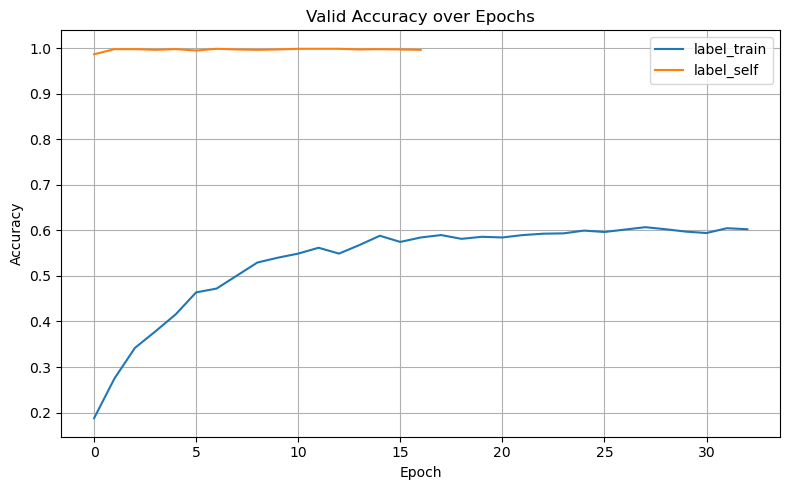

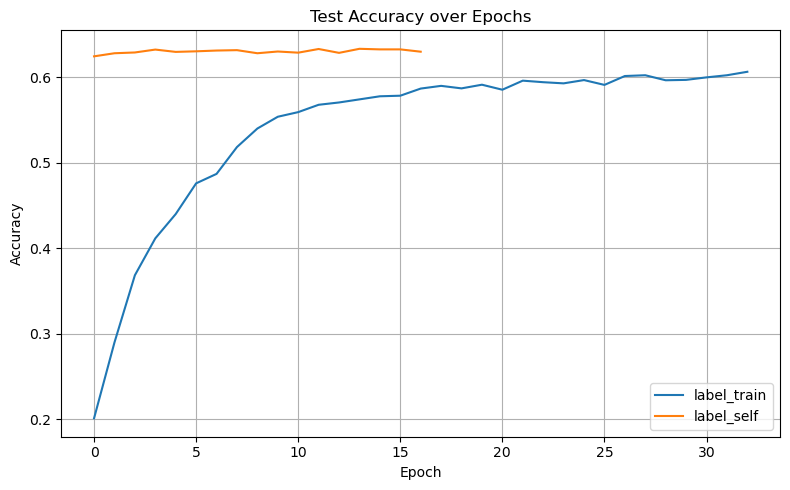

In [62]:
plot_results(results_dict, split="valid")
plot_results(results_dict, split="test")

## Prepare Kaggle submission

In [63]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# === 1. Load test IDs ===
ROOT = Path("../assignment_release/dataset") # Root dataset directory
LABEL_MAP_PATH = ROOT / "category_classification"
TEST_IDS_PATH = LABEL_MAP_PATH / "task1_test_ids.csv"

test_ids_df = pd.read_csv(TEST_IDS_PATH)  # has column "id"
test_ids = test_ids_df["id"].tolist()

# === 2. Custom Dataset (no labels) ===
class ProductCategoryTestDataset(Dataset):
    def __init__(self, pids, pid2idx, embeddings):
        self.pids = pids
        self.indices = [pid2idx[pid] for pid in self.pids]
        self.vecs = embeddings 
        
    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = self.vecs[self.indices[idx]]
        return {"X": torch.tensor(emb, dtype=torch.float)}

# === 3. Build dataset and loader ===
test_dataset_kaggle = ProductCategoryTestDataset(test_ids, pid2idx, embeddings)
test_loader_kaggle = DataLoader(test_dataset_kaggle, batch_size=64)

# === 4. Run predictions ===
model.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader_kaggle:
        X = batch["X"].to(device)  
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().tolist())

# === 5. Build submission file ===
submission = pd.DataFrame({
    "id": test_ids,
    "label": all_preds
})

SUBMISSION_PATH = "submission/P2_submission_08.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Submission file saved to {SUBMISSION_PATH}")
print(submission.head())

Submission file saved to submission/P2_submission_08.csv
           id  label
0  B07X74M6PT    377
1  B07FDRHFWM    770
2  B07MQNYJKB    521
3  B07GDQNZSV    529
4  B08X43BL62    548
